<a href="https://colab.research.google.com/github/evandwh/ST554---Spring-2026---NCSU/blob/main/HW6/Whitfield_ST554_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Evan Whitfield

Course: ST554 (Spring 2026)

Purpose: HW6

#Part 1 - More Practice Querying a Database

## Question 1

First we are going to import and read the schema.

In [24]:
#import sql and pandas
import sqlite3
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Colab Data/lahman_1871-2022 (2).sqlite'

#Create connection
con = sqlite3.connect(file_path)

#create a 'cursor' object from our connection
cursor = con.cursor()

#get schema code
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

schema_df = pd.read_sql(get_schema, con)

print(schema_df)

     type                 name             tbl_name  rootpage  \
0   table          AllstarFull          AllstarFull         2   
1   table          Appearances          Appearances         3   
2   table       AwardsManagers       AwardsManagers         4   
3   table        AwardsPlayers        AwardsPlayers         5   
4   table  AwardsShareManagers  AwardsShareManagers         6   
5   table   AwardsSharePlayers   AwardsSharePlayers         7   
6   table              Batting              Batting         8   
7   table          BattingPost          BattingPost         9   
8   table       CollegePlaying       CollegePlaying        10   
9   table             Fielding             Fielding        11   
10  table           FieldingOF           FieldingOF        12   
11  table      FieldingOFsplit      FieldingOFsplit        13   
12  table         FieldingPost         FieldingPost        14   
13  table           HallOfFame           HallOfFame        15   
14  table            Home

## Question 2

Now we want to use our connection to find all of the Hall of Fame pitchers are look at their career stats. First, we

In [34]:
HoF_pitchers = '''
    SELECT
        p.playerID,
        SUM(p.GS) as Starts,
        SUM(p.G) as Games,
        SUM(p.W) as Wins,
        SUM(p.L) as Losses,
        SUM(p.IPOuts) as Innings_Pictched_Outs,
        SUM(p.CG) as Complete_Games,
        SUM(p.SHO) as Shut_Outs,
        SUM(p.SV) as Saves
    FROM Pitching as p
    JOIN HallOfFame as h
        ON p.playerID = h.playerID
    WHERE inducted = 'Y'
    GROUP BY p.playerID
    '''

HoF_pitchers_df = pd.read_sql(HoF_pitchers, con)
print(HoF_pitchers_df)

      playerID  Starts  Games  Wins  Losses  Innings_Pictched_Outs  \
0    alexape01     599    696   373     208                  15570   
1    ansonca01       0      3     0       1                     12   
2    becklja01       1      1     0       1                     12   
3    bendech01     334    459   212     127                   9051   
4    blylebe01     685    692   287     250                  14910   
..         ...     ...    ...   ...     ...                    ...   
103  willivi01     471    513   249     205                  11988   
104  wrighge01       0      3     0       1                     15   
105  wrighha01       8     36     4       4                    301   
106   wynnea01     612    691   300     244                  13692   
107  youngcy01     815    906   511     315                  22068   

     Complete_Games  Shut_Outs  Saves  
0               437         90     32  
1                 0          0      1  
2                 0          0      0  

## Question 3

Now we want to see the batting statistics of these pictures.

In [38]:
HoF_pitchers_bats = '''
    SELECT
        p.playerID,
        SUM(b.AB) as At_Bats,
        SUM(b.R) as Runs,
        SUM(b.H) as Hits,
        SUM(b.HR) as Home_Runs,
        SUM(b.RBI) as RBIs,
        SUM(b.BB) as Walks,
        SUM(b.SO) as Strike_Outs
    FROM Pitching as p
    JOIN HallOfFame as h
        ON p.playerID = h.playerID
    JOIN Batting as b
        ON p.playerID = b.playerID
    WHERE inducted = 'Y'
    GROUP BY p.playerID
    '''

HoF_pitchers_bats_df = pd.read_sql(HoF_pitchers_bats, con)
print(HoF_pitchers_bats_df)

      playerID  At_Bats  Runs   Hits  Home_Runs  RBIs  Walks  Strike_Outs
0    alexape01    38010  3234   7938        231  3423   1617         5796
1    ansonca01    20562  3998   6870        194  4150   1968          660
2    becklja01     9551  1603   2938         87  1581    616          526
3    bendech01    18352  1632   3888         96  1856   1200         2288
4    blylebe01    10824   456   1416          0   600    120         4632
..         ...      ...   ...    ...        ...   ...    ...          ...
103  willivi01    19409  1391   3224         13  1092   1053         2587
104  wrighge01     5746  1330   1732         22   652    136          238
105  wrighha01     3252   732    896         16   452    148           56
106   wynnea01    39192  3128   8395        391  3979   3243         7590
107  youngcy01    68080  7475  14329        414  6670   1863         8763

[108 rows x 8 columns]


##Question 4
Now we want to combine these two tables together.  I am going to try to do this two different ways.

Way 1 - Make a command that will simply make this into one table in one command instead of two tables with two commands.

Way 2 - Using pd.merge()


In [39]:
HoF_pitchers_all = '''
    SELECT
        p.playerID,
        SUM(p.GS) as Starts,
        SUM(p.G) as Games,
        SUM(p.W) as Wins,
        SUM(p.L) as Losses,
        SUM(p.IPOuts) as Innings_Pictched_Outs,
        SUM(p.CG) as Complete_Games,
        SUM(p.SHO) as Shut_Outs,
        SUM(p.SV) as Saves,
        SUM(b.AB) as At_Bats,
        SUM(b.R) as Runs,
        SUM(b.H) as Hits,
        SUM(b.HR) as Home_Runs,
        SUM(b.RBI) as RBIs,
        SUM(b.BB) as Walks,
        SUM(b.SO) as Strike_Outs
    FROM Pitching as p
    JOIN HallOfFame as h
        ON p.playerID = h.playerID
    JOIN Batting as b
        ON p.playerID = b.playerID
    WHERE inducted = 'Y'
    GROUP BY p.playerID
    '''

HoF_pitchers_all_df = pd.read_sql(HoF_pitchers_all, con)
print(HoF_pitchers_all_df)

      playerID  Starts  Games   Wins  Losses  Innings_Pictched_Outs  \
0    alexape01   12579  14616   7833    4368                 326970   
1    ansonca01       0     81      0      27                    324   
2    becklja01      22     22      0      22                    264   
3    bendech01    5344   7344   3392    2032                 144816   
4    blylebe01   16440  16608   6888    6000                 357840   
..         ...     ...    ...    ...     ...                    ...   
103  willivi01    6123   6669   3237    2665                 155844   
104  wrighge01       0     36      0      12                    180   
105  wrighha01      56    252     28      28                   2107   
106   wynnea01   14076  15893   6900    5612                 314916   
107  youngcy01   18745  20838  11753    7245                 507564   

     Complete_Games  Shut_Outs  Saves  At_Bats  Runs   Hits  Home_Runs  RBIs  \
0              9177       1890    672    38010  3234   7938        

In [41]:
merged_df = pd.merge(left = HoF_pitchers_df, right = HoF_pitchers_bats_df, on = 'playerID')
print(merged_df)

      playerID  Starts  Games  Wins  Losses  Innings_Pictched_Outs  \
0    alexape01     599    696   373     208                  15570   
1    ansonca01       0      3     0       1                     12   
2    becklja01       1      1     0       1                     12   
3    bendech01     334    459   212     127                   9051   
4    blylebe01     685    692   287     250                  14910   
..         ...     ...    ...   ...     ...                    ...   
103  willivi01     471    513   249     205                  11988   
104  wrighge01       0      3     0       1                     15   
105  wrighha01       8     36     4       4                    301   
106   wynnea01     612    691   300     244                  13692   
107  youngcy01     815    906   511     315                  22068   

     Complete_Games  Shut_Outs  Saves  At_Bats  Runs   Hits  Home_Runs  RBIs  \
0               437         90     32    38010  3234   7938        231  3423   

It looks like we were successful in creating the merged dataframe both ways!

#Part 2 - Messing with Classes

Below we are making a class to do various things per the instructions of the homework.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class SLR_slope_simulator:

    def __init__(self, beta_0, beta_1, x, sigma, seed):

        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma
        self.x = np.array(x)
        self.n = len(x)
        self.rng = np.random.default_rng(seed)
        self.slopes = []

    def generate_data(self):
        """
        Generate one dataset based on the SLR model:
        y = beta_0 + beta_1*x + epsilon
        Data set will returned in a list containing two arrays, one for each variable.
        """
        epsilon = self.rng.normal(0, self.sigma, self.n)
        y = self.beta_0 + self.beta_1 * self.x + epsilon
        return self.x, y

    def fit_slope(self, x, y):
        """
        Fit an SLR and return the estimated slope (beta_1_hat)
        """

        x_bar = np.mean(x)
        y_bar = np.mean(y)

        top = np.sum((x - x_bar) * (y - y_bar))
        bottom = np.sum((x - x_bar)**2)

        beta_1_hat = top / bottom
        return beta_1_hat


    def run_simulations(self, num_simulations):
        """
        Run multiple simulations and store slope estimates in an array.
        """

        #Use local slopes incase run_simulations is ran twice. I guess we could also clear self.slopes at this point. I'm not sure what the better practice would be.
        local_slopes = []
        for _ in range(num_simulations):
            x, y = self.generate_data()
            slope_hat = self.fit_slope(x, y)
            local_slopes.append(slope_hat)

        self.slopes = np.array(local_slopes)

    def plot_sampling_distribution(self):
        """
        Plot a histogram of the slope estimates that were generated using run_simulations().
        """
        if len(self.slopes) == 0:
            print("You must call run_simulations() first!")
        else:
            plt.hist(self.slopes, bins = 30)
            plt.xlabel("Slope Estimates")
            plt.ylabel("Frequency")
            plt.title("Approx. Sampling Distribution of Slope Estimates")
            plt.show()

    def find_prob(self, value, sided):
        """
        Finding the probablily using simulated data that the slope is as extreme
        or more extreme than the value provided under the side specified.
        """
        if len(self.slopes) == 0:
            print("You must run run_simulations() first.")
            return

        n = len(self.slopes)

        if sided == "above":
            prob = np.sum(self.slopes > value) / n

        elif sided == "below":
            prob = np.sum(self.slopes < value) / n

        elif sided == "two-sided":
            median = np.median(self.slopes)

            if value > median:
                prob = 2 * (np.sum(self.slopes > value) / n)
            else:
                prob = 2 * (np.sum(self.slopes < value) / n)

        #If someone did not use the correct word for sided.
        else:
            print("You did not give correct value for sided. Must be either 'above', 'below', or 'two-sided'.")
            return

        return prob

We are finished with our class building. Now we are ready to test it out and see if it works properly!

You must call run_simulations() first!


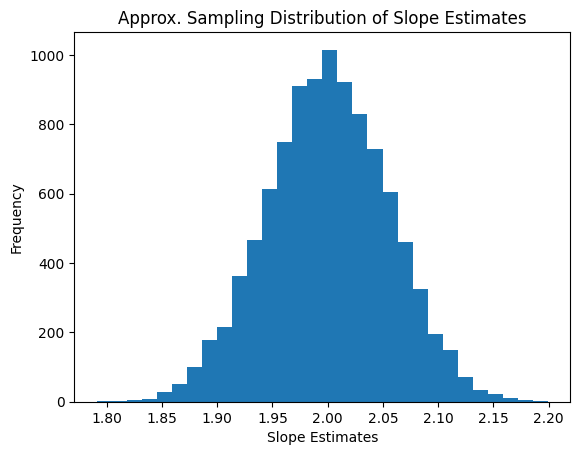

Two-sided probability: 0.0704
[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]


In [2]:
#Testing the code out using the instructions from class.

sim = SLR_slope_simulator(beta_0=12, beta_1=2,
                          x=np.array(list(np.linspace(start=0, stop=10, num=11)) * 3),
                          sigma=1, seed=10
)

#Testing to see if method gives the correct error.
sim.plot_sampling_distribution()

# Running 10000 simulations
sim.run_simulations(10000)

# Plotting our slope estimates
sim.plot_sampling_distribution()

# Approximating the probability it is more extreme that 2.1
prob = sim.find_prob(2.1, "two-sided")
print("Two-sided probability:", prob)

# Print simulated slopes
print(sim.slopes)

It seems like it worked properly! Only time will tell if I happen to get an 100 on this assignment!